# C4 – Suitable Intervention Prediction

Predicts the most suitable intervention for a student from four inputs:

| Input | Values |
|---|---|
| `C1_Condition` | Exam Anxiety, Conceptual Confusion, Academic Helplessness, Course Pacing Frustration, Motivation Erosion |
| `C2_Trajectory` | Stable, Improving, Declining, Volatile |
| `Risk_Tier` | Low, Medium, High, Critical |
| `C3_Vector` | Affective / Behavioural / Academic scores |

**Steps:** 1 Upload → 2 Explore → 3 Preprocess → 4 Split → 5 Train → 6 Test → 7 Save → 8 Predict

Run the cells from top to bottom (**Runtime → Run all**) and upload
`C4_ML_Training_Dataset_500_IT23_v2.xlsx` when asked.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report, ConfusionMatrixDisplay

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

TARGET = "Suitable_Intervention"
RANDOM_STATE = 42


def upload_file(default_path):
    """In Colab, open the upload dialog and return the file name. Elsewhere, use default_path."""
    if IN_COLAB:
        return next(iter(files.upload()))
    return default_path


def read_table(path):
    """Read a .csv file, or the first sheet of an Excel file."""
    if path.lower().endswith(".csv"):
        return pd.read_csv(path)
    return pd.read_excel(path, sheet_name=0)

## 1. Upload the dataset

In [2]:
DATA_PATH = upload_file("C4_ML_Training_Dataset_500_IT23_v2.xlsx")
df = read_table(DATA_PATH)
print(DATA_PATH, df.shape)
df.head()

C4_ML_Training_Dataset_500_IT23_v2.xlsx (500, 8)


,Student_ID,Record_ID,C1_Condition,C2_Trajectory,Risk_Tier,C3_Vector,Risk_Probability,Suitable_Intervention
0,IT23125208,REC0001,Academic Helplessness,Volatile,High,"Affective: 0.15, Behavioural: 0.39, Academic: ...",0.68,Financial Support
1,IT23228068,REC0002,Motivation Erosion,Declining,High,"Affective: 0.33, Behavioural: 0.36, Academic: ...",0.65,Attendance Support
2,IT23130934,REC0003,Exam Anxiety,Improving,Low,"Affective: 0.26, Behavioural: 0.55, Academic: ...",0.24,Peer Mentoring
3,IT23323629,REC0004,Course Pacing Frustration,Declining,Critical,"Affective: 0.39, Behavioural: 0.39, Academic: ...",0.89,Referral to Relevant Services
4,IT23893711,REC0005,Conceptual Confusion,Improving,Low,"Affective: 0.38, Behavioural: 0.25, Academic: ...",0.04,Academic Support


## 2. Explore

Missing values per column:
Student_ID               0
Record_ID                0
C1_Condition             0
C2_Trajectory            0
Risk_Tier                0
C3_Vector                0
Risk_Probability         0
Suitable_Intervention    0

Duplicate rows: 0


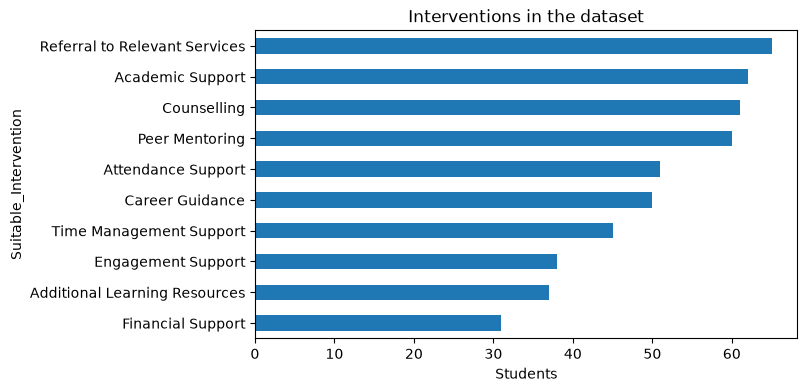

In [3]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())

df[TARGET].value_counts().plot(kind="barh", figsize=(7, 4), title="Interventions in the dataset")
plt.gca().invert_yaxis()
plt.xlabel("Students")
plt.show()

## 3. Preprocess

- Remove rows without a target and remove duplicate rows.
- Tidy the text columns (trim spaces, consistent capitals).
- Turn `C3_Vector` into **`C3_Dominant`**: whichever of Affective, Behavioural or Academic has the highest score.
- `Student_ID` and `Record_ID` are identifiers, not features. `Risk_Probability` is only the number behind
  `Risk_Tier`, so the tier is enough.

In [4]:
FEATURES = ["C1_Condition", "C2_Trajectory", "Risk_Tier", "C3_Dominant"]


def strongest_c3(text):
    """'Affective: 0.15, Behavioural: 0.39, Academic: 0.46' -> 'Academic'"""
    scores = {}
    for part in str(text).split(","):
        name, value = part.split(":")
        scores[name.strip().title()] = float(value)
    return max(scores, key=scores.get)


def prepare_features(data):
    """Raw student records -> the four model inputs."""
    data = data.copy()
    for col in ["C1_Condition", "C2_Trajectory", "Risk_Tier"]:
        data[col] = data[col].astype(str).str.strip().str.title()
    data["C3_Dominant"] = data["C3_Vector"].apply(strongest_c3)
    return data[FEATURES]


df = df.dropna(subset=[TARGET]).drop_duplicates()
X = prepare_features(df)
y = df[TARGET]
print("Rows used:", len(X))
X.head()

Rows used: 500


,C1_Condition,C2_Trajectory,Risk_Tier,C3_Dominant
0,Academic Helplessness,Volatile,High,Academic
1,Motivation Erosion,Declining,High,Behavioural
2,Exam Anxiety,Improving,Low,Behavioural
3,Course Pacing Frustration,Declining,Critical,Affective
4,Conceptual Confusion,Improving,Low,Affective


## 4. Split into train and test sets (80 / 20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (400, 4)   Test: (100, 4)


## 5. Train

Each model is a pipeline: one-hot encode the four inputs, then classify.
Three models are scored with 5-fold cross-validation on the training set, and the one with the best
mean accuracy is trained on the whole training set.

In [6]:
def make_pipeline(classifier):
    encoder = ColumnTransformer([("onehot", OneHotEncoder(handle_unknown="ignore"), FEATURES)])
    return Pipeline([("encode", encoder), ("model", clone(classifier))])


candidates = {
    "Logistic Regression": LogisticRegression(C=10, max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {}
for name, classifier in candidates.items():
    scores = cross_val_score(make_pipeline(classifier), X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores[name] = scores.mean()
    print(f"{name:20s} CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

best_name = max(cv_scores, key=cv_scores.get)
model = make_pipeline(candidates[best_name]).fit(X_train, y_train)
print("\nSelected model:", best_name)

Logistic Regression  CV accuracy = 0.863 ± 0.046


Random Forest        CV accuracy = 0.872 ± 0.058


Gradient Boosting    CV accuracy = 0.900 ± 0.040



Selected model: Gradient Boosting


## 6. Test on the held-out 20%

Test accuracy:       0.880
Test top-3 accuracy: 0.930

                               precision    recall  f1-score   support

             Academic Support       0.92      1.00      0.96        12
Additional Learning Resources       1.00      0.88      0.93         8
           Attendance Support       0.82      0.90      0.86        10
              Career Guidance       0.91      1.00      0.95        10
                  Counselling       0.71      0.83      0.77        12
           Engagement Support       1.00      1.00      1.00         8
            Financial Support       1.00      1.00      1.00         6
               Peer Mentoring       0.73      0.67      0.70        12
Referral to Relevant Services       0.92      0.92      0.92        13
      Time Management Support       1.00      0.67      0.80         9

                     accuracy                           0.88       100
                    macro avg       0.90      0.89      0.89       100
                 wei

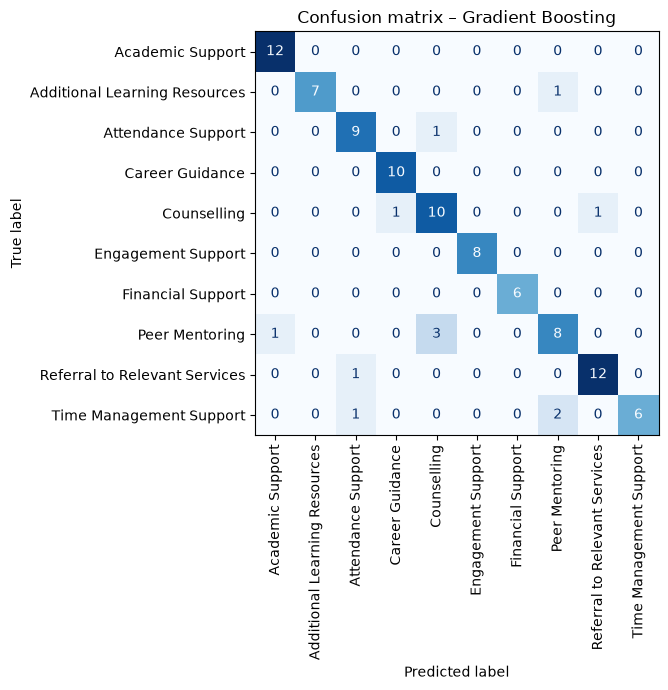

In [7]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)
print(f"Test accuracy:       {accuracy_score(y_test, pred):.3f}")
print(f"Test top-3 accuracy: {top_k_accuracy_score(y_test, proba, k=3, labels=model.classes_):.3f}\n")
print(classification_report(y_test, pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation=90, cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"Confusion matrix – {best_name}")
plt.tight_layout()
plt.show()

## 7. Save the final model

The final model is retrained on all rows, so it learns from every example, then saved.

In [8]:
final_model = make_pipeline(candidates[best_name]).fit(X, y)
joblib.dump(final_model, "c4_intervention_model.joblib")
print("Saved c4_intervention_model.joblib")
if IN_COLAB:
    files.download("c4_intervention_model.joblib")

# In a later session, run the setup and section 3 cells, then:
# final_model = joblib.load("c4_intervention_model.joblib")

Saved c4_intervention_model.joblib


## 8. Predict (inference)

`recommend()` takes raw student records (same columns as the training file, without the target)
and returns the predicted intervention plus the top 3 options with their probabilities.

In [9]:
def recommend(data, model=final_model, top_k=3):
    proba = model.predict_proba(prepare_features(data))
    ranked = np.argsort(proba, axis=1)[:, ::-1][:, :top_k]
    result = pd.DataFrame({"Predicted_Intervention": model.classes_[ranked[:, 0]]}, index=data.index)
    for k in range(top_k):
        result[f"Option_{k + 1}"] = [f"{model.classes_[j]} ({p[j]:.0%})" for j, p in zip(ranked[:, k], proba)]
    return result

In [10]:
#@title Predict for one student
C1_Condition = "Exam Anxiety"  #@param ["Exam Anxiety", "Conceptual Confusion", "Academic Helplessness", "Course Pacing Frustration", "Motivation Erosion"]
C2_Trajectory = "Declining"  #@param ["Stable", "Improving", "Declining", "Volatile"]
Risk_Tier = "High"  #@param ["Low", "Medium", "High", "Critical"]
Affective = 0.5  #@param {type:"slider", min:0, max:1, step:0.01}
Behavioural = 0.3  #@param {type:"slider", min:0, max:1, step:0.01}
Academic = 0.2  #@param {type:"slider", min:0, max:1, step:0.01}

student = pd.DataFrame([{
    "C1_Condition": C1_Condition,
    "C2_Trajectory": C2_Trajectory,
    "Risk_Tier": Risk_Tier,
    "C3_Vector": f"Affective: {Affective}, Behavioural: {Behavioural}, Academic: {Academic}",
}])
recommend(student).T

,0
Predicted_Intervention,Counselling
Option_1,Counselling (86%)
Option_2,Time Management Support (3%)
Option_3,Attendance Support (3%)


In [11]:
#@title Predict for a file of students (optional)
PREDICT_FILE = False  #@param {type:"boolean"}

if PREDICT_FILE:
    new_path = upload_file(DATA_PATH)
    new_df = read_table(new_path)
    predictions = pd.concat([new_df, recommend(new_df)], axis=1)
    predictions.to_csv("c4_predictions.csv", index=False)
    print("Saved c4_predictions.csv")
    if IN_COLAB:
        files.download("c4_predictions.csv")
    display(predictions.head(10))

## Notes

- The model uses `C1_Condition`, `C2_Trajectory`, `Risk_Tier` and the strongest C3 dimension.
- The v2 dataset labels follow clear intervention rules (see its README sheet), and about 7% of rows
  are left as noise. The best possible accuracy is therefore a little over 90%.
- The original `C4_ML_Training_Dataset_500_IT23.xlsx` also runs in this notebook, but its labels are
  close to random, so accuracy stays around 20%.
- This is synthetic prototype data. The results show the pipeline works; they are not evidence that
  an intervention works for real students.